In [ ]:
!pip install git+https://github.com/LAL/trackml-library.git
import numpy as np 
import pandas as pd 
import zipfile # Descomprimir archivos .zip
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from trackml.score import score_event
import os  # Solo lo usé para obtener las rutas hazta los archivos .zip
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import (confusion_matrix,classification_report,ConfusionMatrixDisplay)

# Funciones de variables espaciales

In [5]:
# Definimos una función para ver que partículas son cercanas y etiquetarlas en un grupo.
def etiqueta_grupos(hits, eps=0.015):
    '''
    Primero extraemos las coordenadas espaciales donde ocurrió el impacto del archivo de hits.
    Como lo que tenemos es un detector cilindrico, lo mejor es trabajar en coordenadas cilíndricas.
    Definimos el radio, el ángulo y una magnitud llamada z_rel. Esta es porque como tenemos una 
    especie de hélice cónica, el avance en el eje z entre el radio de la helice es una magnitud constante.
    '''
    
    # Obtenemos las coordenadas y obtenemos el radio y el ángulo correspondiente
    x = hits['x']
    y = hits['y']
    z = hits['z']
    r = np.sqrt(x**2+y**2)
    phi = np.arctan2(y,x) 
    theta = np.arctan2(r,z)
    z_rel = z/(r+10**(-6))
    eta = -np.log(np.tan(theta/2))
    # Agrupamos las variables en coordenadas cilindricas en un array y las normalizaremos
    X = np.column_stack([np.cos(phi), np.sin(phi) ,z_rel, eta])
    # X = np.column_stack([theta,z_rel])
    X_scaled = StandardScaler().fit_transform(X)

    # Creamos los clusters, es decir, los grupos de partículas vecinas
    # Tomamos el algoritmo DBSCAN para saber cuantas partículas hay dentro de la esfera de radio eps
    # Exigimos que a partir de una particula en el interior de ese radio sea ya un cluster (min_sample = 1)
    # El algoritmo de optimización usado será el 'kd_tree'
    clusters = DBSCAN(eps=eps, min_samples=1, algorithm='kd_tree')
    etiquetas = clusters.fit_predict(X_scaled) # Nos devuelve las etiquetas del grupo al que pertenece cada partícula
    return etiquetas # Hay etiquetas con -1, significa que son ruido. No pertenecen a ningún grupo. Las eliminaré después.

def features_hits(hits, cells, detectors):
    grupo = etiqueta_grupos(hits) # Con el DBSCAN asignamos una etiqueta a cada hit
    hits = hits.merge(detectors, on=["volume_id","layer_id","module_id"], how="left") # Combinamos hits con el archivo de detectors
    hit_cells = cells.groupby('hit_id').size() # Contamos el número de celdas sobre las que se deposita energía
    hit_value = cells.groupby('hit_id')['value'].sum() # Obtenemos el total de energía depositada por cada partícula

    # Ordenamos los hits con .reindex.
    hit_cells = hit_cells.reindex(hits.hit_id).fillna(0).values
    hit_value = hit_value.reindex(hits.hit_id).fillna(0).values

    # Obtengo las variables espaciales
    x = hits['x'].values/1000
    y = hits['y'].values/1000
    z = hits['z'].values/1000
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y,x) 
    theta = np.arctan2(r,z)
    eta = -np.log(np.tan(theta/2))
    rho = np.sqrt(x*x+y*y+z*z)
    zr = z/(r+1e-6)
    rz = r/(np.abs(z)+1e-6)
    
    # Coordenadas geométricas del módulo detector donde se registró el impacto.
    # Aporta información adicional sobre la geometria del detector.
    # En metros
    cx = hits.cx.values/1000
    cy = hits.cy.values/1000
    cz = hits.cz.values/1000

    # Vector perpendicular al plano del sensor donde impacta la partícula
    rot_xw = hits.rot_xw.values
    rot_yw = hits.rot_yw.values
    rot_zw = hits.rot_zw.values
    
    # Las meto en un mismo array ya normalizadas
    features = np.column_stack([x, y, z, cx, cy, cz, rot_xw, rot_yw, rot_zw, r, rho, np.cos(phi), np.sin(phi), eta, zr, rz, hit_cells/10, hit_value])
    return features, grupo

In [11]:
evento = 'event000001001'
ruta_train1 = '/kaggle/input/competitions/trackml-particle-identification/train_1.zip'
zipi = zipfile.ZipFile(ruta_train1,'r')
hits = pd.read_csv(zipi.open(f'train_1/{evento}-hits.csv'))
cells = pd.read_csv(zipi.open(f'train_1/{evento}-cells.csv'))
truth = pd.read_csv(zipi.open(f'train_1/{evento}-truth.csv'))
zipi.close()

ruta_detectors = '/kaggle/input/competitions/trackml-particle-identification/detectors.zip'
# Abrimos el de detectores y obtenemos sus datos
zd = zipfile.ZipFile(ruta_detectors, "r")
detectors = pd.read_csv(zd.open("detectors.csv"))
zd.close()

In [7]:
# DNN
class tracker(nn.Module):
    def __init__(self, input_dim=37):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 800),
            nn.SELU(),

            nn.Linear(800, 400),
            nn.SELU(),

            nn.Linear(400, 400),
            nn.SELU(),

            nn.Linear(400, 400),
            nn.SELU(),

            nn.Linear(400, 200),
            nn.SELU(),

            nn.Linear(200, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)
device = torch.device("cuda")
modelo = tracker().to(device)  # device = cuda:0
modelo.load_state_dict(torch.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan-37/modelo_hard.pt"))
modelo.eval()
preds=np.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan-37/preds_event001_50.npy",allow_pickle=True)
tracks=np.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan-37/tracks_event001_50.npy",allow_pickle=True)
tracks = tracks.astype(np.int32)
'''
N = 50000
truth = truth.iloc[:N].reset_index(drop=True)
submission = pd.DataFrame({"hit_id":truth.hit_id.values,"track_id":tracks.astype(int)})
score = score_event(truth,submission)
print("----------------------------")
print("FINAL")
print("-------------------------------")
print("Score =", score*100 ,'%')
'''

----------------------------
FINAL
-------------------------------
Score = 52.309778845914835 %


# FUNCIONES

In [8]:
# Contamos los impactos registrados en cada módulo del detector
count = hits.groupby(['volume_id','layer_id','module_id'])['hit_id'].count().values 

# Obtenemos en qué modulo del detector cae cada impacto
module_id = np.zeros(len(hits),dtype=np.int32)
for i in range(len(count)):
    si = np.sum(count[:i])
    module_id[si:si+count[i]] = i
    
den = 37 # neuronas en la capa de entrada
en = 18 # número de features


# Con esta función se calcula, para un hit, la probabilidad de que el resto pertenezcan a al trayectoria
def get_predict(hit, thr=0.5):
    Tx = np.zeros((len(features), den), dtype=np.float32) # Matriz de entrada
    Tx[:, :en] = np.tile(features[hit], (len(features), 1)) # Añadimos las features del hit
    Tx[:, en:2*en] = features # La segunda parte son el resto de features del resto de hits
    Tx[:, 2*en] = (grupos[hit] == grupos).astype(np.float32) # Variable que nos dice que impactos pertenecen al mismo grupo generado con DBSCAN

    # Para cada batch devolvemos la predicción asociada
    with torch.no_grad():
        pred = []
        batch_size = 20000
        for i in range(0,len(Tx),batch_size):
            batch = torch.tensor(Tx[i:i+batch_size],dtype=torch.float32).to(device)
            pred.append(modelo(batch).cpu().numpy())

        pred = np.concatenate(pred).ravel()
    # Realizamos un modelo de inferencia para las probabilidades llamado Test Time Argumentation TTA
    # Los índices para los cuales la probabilidad supere el umbral establecido realizaremos un intercambio
    idx = np.where(pred > thr)[0] 
    if len(idx) > 0:
        Tx2 = np.zeros((len(idx),den),dtype=np.float32)
        # Intercambiamos los dos hits
        Tx2[:, :en] = Tx[idx, en:2*en]
        Tx2[:, en:2*en] = Tx[idx, :en]
        
        # same_cluster permanece igual
        Tx2[:, 2*en] = Tx[idx, 2*en]

        # Obtenemos las predicciones para los datos ahora intercambiados
        with torch.no_grad():
            pred1 = []
            for i in range(0,len(Tx2),batch_size):
                batch = torch.tensor(Tx2[i:i+batch_size],dtype=torch.float32).to(device)
                pred1.append(modelo(batch).cpu().numpy())
            pred1 = np.concatenate(pred1).ravel()
            
        # La probabilidad final sera la media entre las dos
        pred[idx] = (pred[idx]+ pred1) / 2

    return pred

# FUNCIÓN PARA FORMAR LA TRAYECTORIA
def get_path(hit, mask, thr):
    path = [hit] # Inicio de la trayectoria, solo un hit
    a = 0
    
    while True:
        c = get_predict(path[-1],thr/2) # Calculamos las probabilidades con respecto al ultimo camino añadido
        mask = (c > thr) * mask # Eliminamos los candidatos que no cumplen el umbral
        mask[path[-1]] = 0 # Tambien se elimina ese impacto

        # Ahora donde la probabilidad SÍ supere el umbral
        cand = np.where(c > thr)[0]
        if len(cand) > 0:
            # Impedimos que una misma trayectoria contenga dos impactos registrados en el mismo módulo
            # (una partícula no puede producir dos impactos a la vez)
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0
        
        a = (c + a) * mask # Acumulamos la probabilidad
        
        # Si ningun candidato supera el criterio salimos del bucle
        if a.max() < thr*len(path):
            break
        # Sino añadimos el candidato al camino
        path.append(int(a.argmax()))

    return sorted(path)

# Con esta funcion se asigna una puntuación de calidad a cada trayectoria reconstruida 
# analizando la coherencia de las conexiones entre sus hits.
def get_track_score(tracks_all, n=4):
    scores = np.zeros(len(tracks_all),dtype=np.float32) # Creamos un array de ceros con la longitud del array de tracks
    # Recorremos cada trayectoria 
    for i, path in enumerate(tracks_all):
        count = len(path) # contamos cuantos hits hay
        # Solo toma en cuenta aquellos con más de un hit
        if count > 1:
            tp = 0 # inicializamos los true positives que contarán como trayectoria correcta
            fp = 0 # inicializamos los false positives que contarán como trayectoria incorrecta
            
            # para cada hit
            for p in path:
                tp += np.sum(np.isin(tracks_all[p],path,assume_unique=True)) # Cuantos de los hits pertenecen a la trayectoria
                fp += np.sum(np.isin(tracks_all[p],path,assume_unique=True,invert=True)) # Cuantos no pertenecen a la trayectoria
            scores[i] = (tp- fp*n- count) / count / (count-1) # Cálculo de la coherencia
        else:
            scores[i] = -np.inf
    return scores


# Devuelve información sobre esas trayectorias, la más destacable el score oficial
def evaluate_tracks(tracks, truth):
    submission = pd.DataFrame({'hit_id':truth.hit_id.values,'track_id':tracks.astype(int)})
    score = score_event(truth,submission)
    track_id = tracks.max()
    print("RESULTADOS")
    print(f"Score = {score*100:.2f}%")
    print(f"Tracks reconstruidas: {tracks.max()}")
    print(f"Hits asignados: {np.sum(tracks > 0)}")
    print(f"Hits sin asignar: {np.sum(tracks == 0)}")

# Función para extender trayectorias. Se intentan alargar.
# Es muy similar a get_path2 en su primera parte
def extend_path(path,mask,thr,last=False):
    a = 0
    
    for p in path[:-1]: # Recorremos todos los hits de la trayectoria salvo el ultimo
        c = get_predict2(p) # probabilidades
        
        if last == False:
            mask = (c > thr) * mask # Se eliminan los candidatos que no superen el umbral
        mask[p] = 0 # Se elimina ese hit de la trayectoria
        cand = np.where( c > thr)[0]
        if len(cand) > 0:
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0 # Se eliminan los del mismo módulo
        a = (c + a) * mask
    
    # Aquí se extiende
    while True:
        c = get_predict2(path[-1]) # solo estudiamos las conexiones del último hit
        
        if last == False:
            mask = (c > thr) * mask
        mask[path[-1]] = 0
        cand = np.where(c > thr)[0]
        
        if len(cand) > 0:
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0
        a = (c + a) * mask 
        
        # Si el candidato es malo nos salimos y sino se añade al camino
        if a.max() < thr * len(path):
            break  
        path.append(int(a.argmax()))
        
        if last:
            break
            
    return path


hit_id = 1
reconstruct : [0, 1228, 1259, 2656, 2720, 4427, 4477, 6494, 6568, 6624, 8927, 9006, 9024, 11361]
ground truth: [0, 1236, 1259, 2656, 2711, 4429, 4501, 6492, 6568, 6624, 8927, 9006, 9024, 11361]

hit_id = 2
reconstruct : [1, 1270, 1314, 2703, 2763, 4478, 4546, 6482, 6527, 6607, 8917, 9003, 9038, 11366]
ground truth: [1, 1270, 1314, 2703, 2763, 4478, 4546, 6482, 6527, 6607, 8917, 9003, 9038, 11366]

hit_id = 3
reconstruct : [2, 1258, 2709, 2756, 4428, 4480, 4529, 6480, 6541, 6608, 8925]
ground truth: [2, 1258, 2709, 2756, 4428, 4480, 4529, 6480, 6541, 6608, 8925]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



hit_id = 4
reconstruct : [3, 40, 1265, 1299, 2716, 2761, 4490, 4548, 6554, 6600, 8939, 8997, 9058, 11365]
ground truth: [3, 40, 1265, 1299, 2716, 2761, 4490, 4548, 6554, 6600, 8939, 8997, 9058, 11365]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


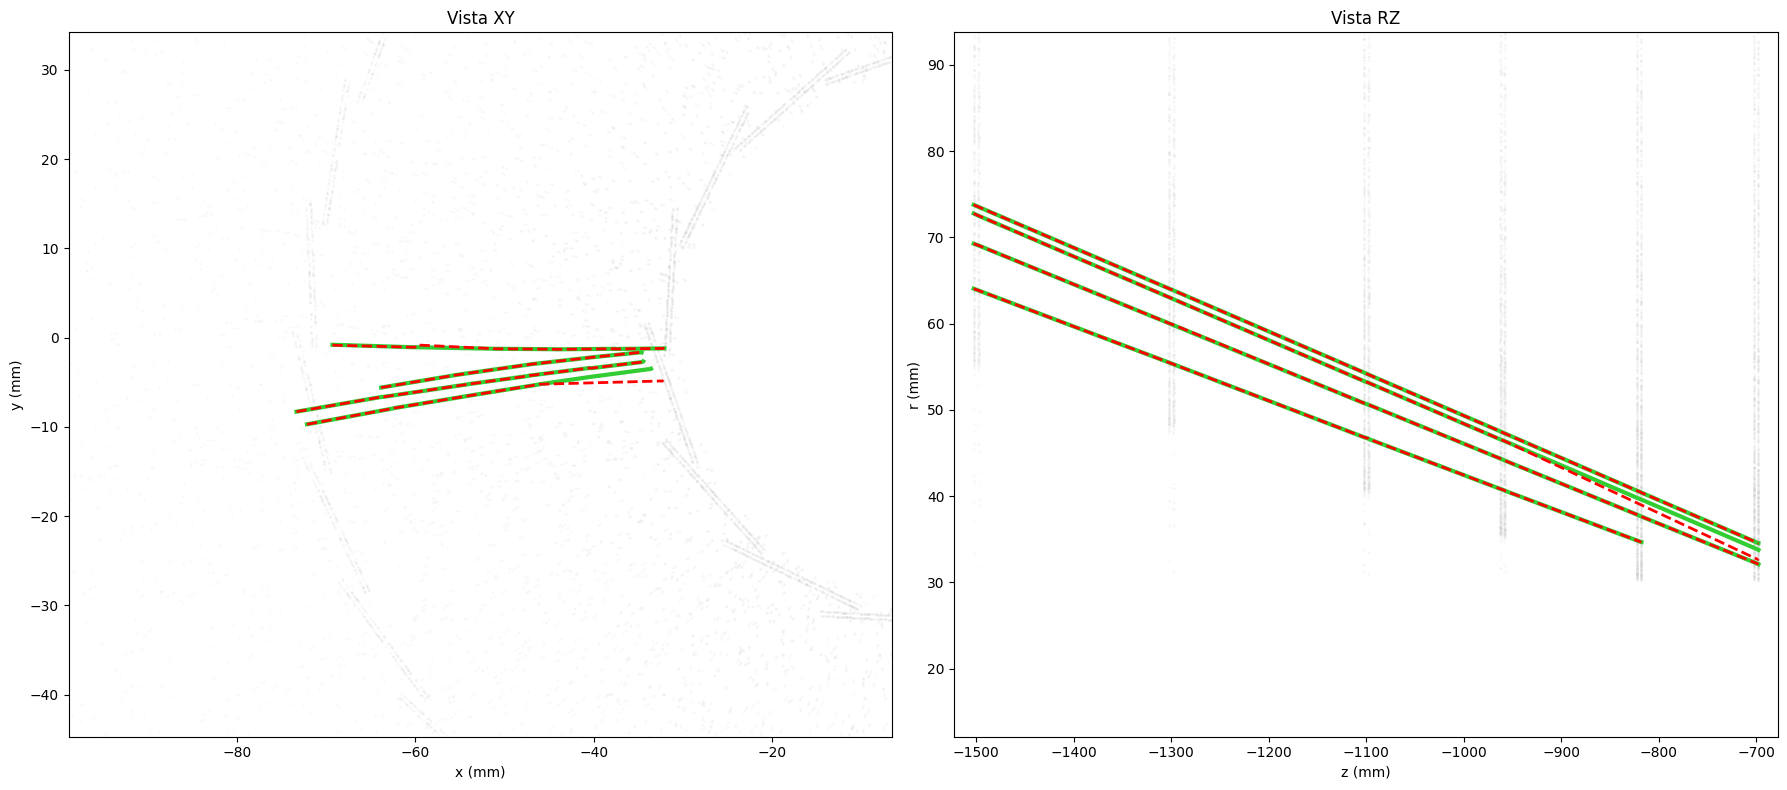

In [12]:
features, grupos = features_hits(hits, cells, detectors)

for hit in range(4):
    path = get_path(hit,np.ones(len(truth)),0.9)
    gt = np.where(truth.particle_id.values==truth.particle_id.iloc[hit])[0]

    print()
    print("hit_id =", hit+1)
    print("reconstruct :", path)
    print("ground truth:", gt.tolist())
    
import matplotlib.pyplot as plt
import numpy as np
x_all = []
y_all = []
z_all = []
r_all = []
r = np.sqrt(hits.x.values**2 + hits.y.values**2)

fig, ax = plt.subplots(1,2,figsize=(18,8))

# Fondo
ax[0].scatter(hits.x, hits.y,
              s=1,
              color="lightgray",
              alpha=0.08)

ax[1].scatter(hits.z, r,
              s=1,
              color="lightgray",
              alpha=0.08)

# Primeras 10 partículas verdaderas
particle_ids = truth.particle_id.unique()
particle_ids = particle_ids[particle_ids != 0][:4]

for pid in particle_ids:

    # Hits verdaderos
    gt = np.where(truth.particle_id.values == pid)[0]

    # Track reconstruido que contiene la mayoría de esos hits
    track = np.bincount(tracks[gt]).argmax()

    if track == 0:
        continue

    rec = np.where(tracks == track)[0]

    # ---------- VERDADERA (VERDE)
    ax[0].plot(hits.x.iloc[gt],hits.y.iloc[gt],'-',color='limegreen',linewidth=3)
    ax[1].plot(hits.z.iloc[gt],r[gt],'-',color='limegreen',linewidth=3)

    # ---------- RECONSTRUIDA (ROJO)
    ax[0].plot(hits.x.iloc[rec],hits.y.iloc[rec],'--',color='red',linewidth=2)
    ax[1].plot(hits.z.iloc[rec],r[rec],'--',color='red',linewidth=2)
    
    x_all.extend(hits.x.iloc[gt])
    x_all.extend(hits.x.iloc[rec])
    
    y_all.extend(hits.y.iloc[gt])
    y_all.extend(hits.y.iloc[rec])
    
    z_all.extend(hits.z.iloc[gt])
    z_all.extend(hits.z.iloc[rec])
    
    r_all.extend(r[gt])
    r_all.extend(r[rec])

ax[0].set_title("Vista XY")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")
ax[0].axis("equal")

ax[1].set_title("Vista RZ")
ax[1].set_xlabel("z (mm)")
ax[1].set_ylabel("r (mm)")
margen = 20

ax[0].set_xlim(min(x_all)-margen, max(x_all)+margen)
ax[0].set_ylim(min(y_all)-margen, max(y_all)+margen)

ax[1].set_xlim(min(z_all)-margen, max(z_all)+margen)
ax[1].set_ylim(min(r_all)-margen, max(r_all)+margen)
plt.tight_layout()

plt.savefig("trayectorias_reconstruidas.png",dpi=600,bbox_inches="tight")
plt.savefig("trayectorias_reconstruidas.pdf",bbox_inches="tight")

plt.show()


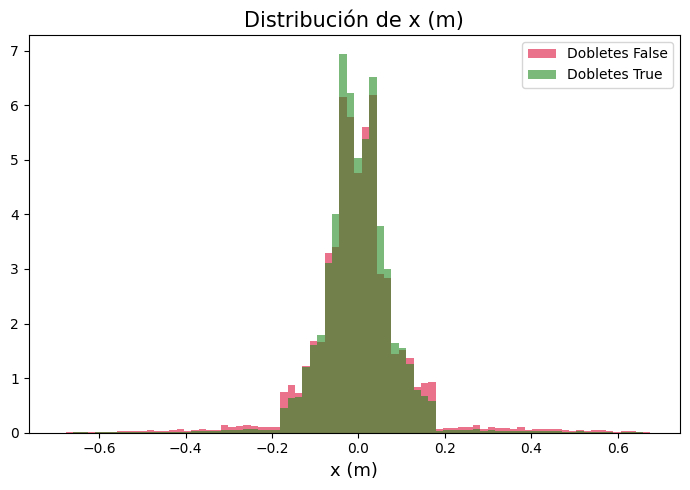

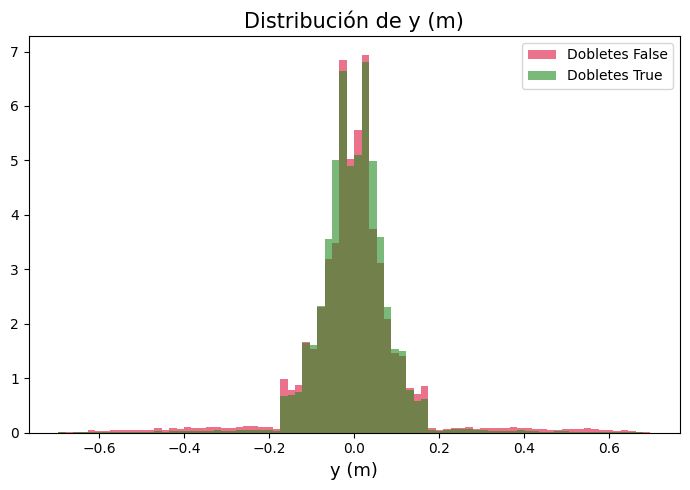

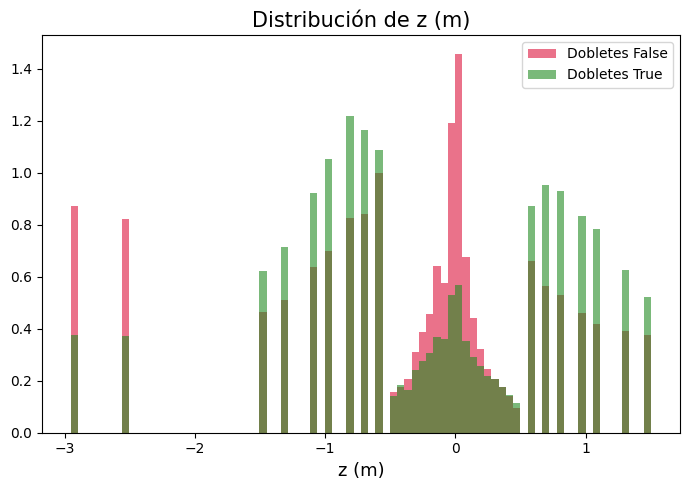

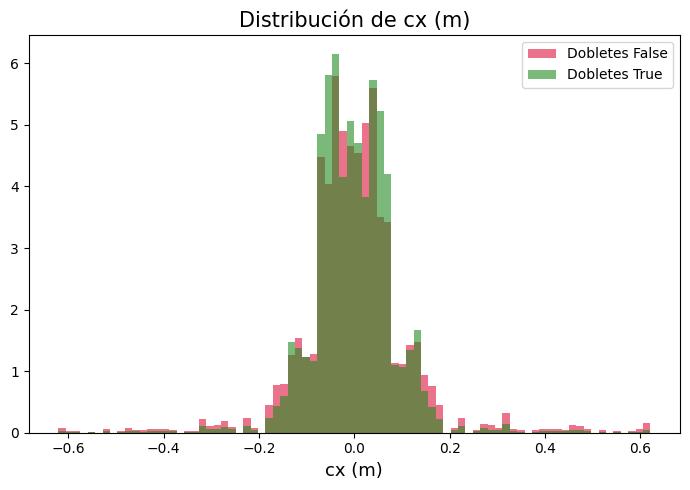

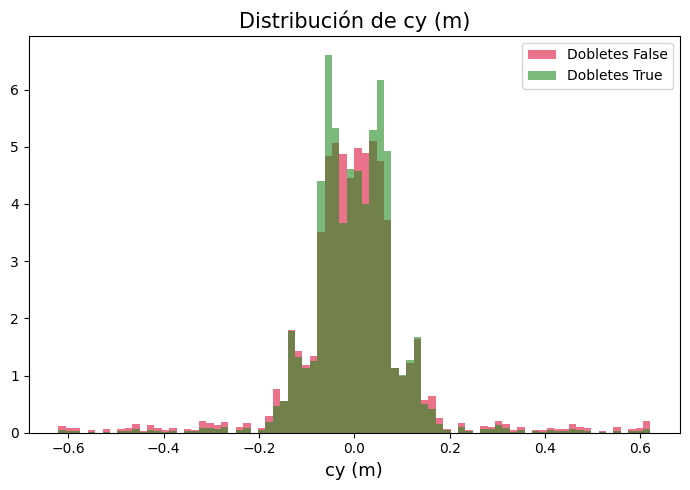

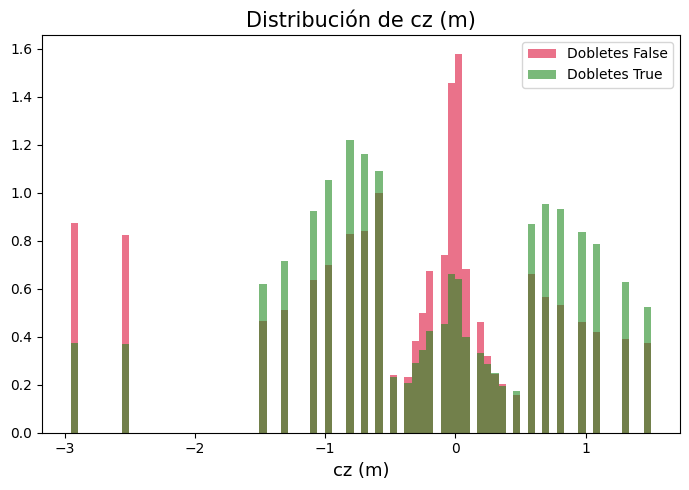

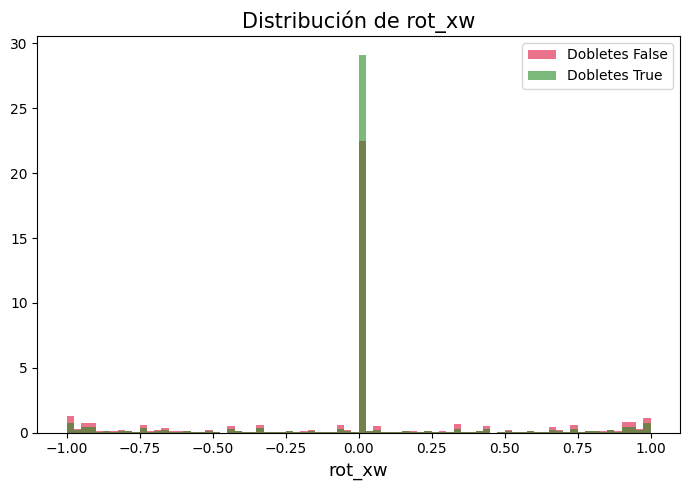

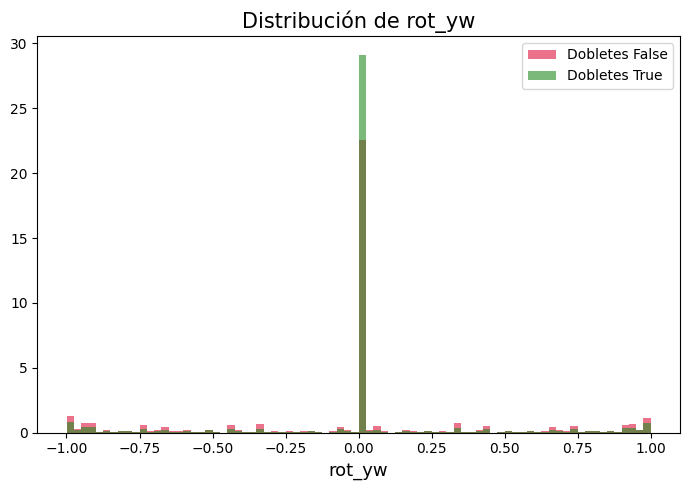

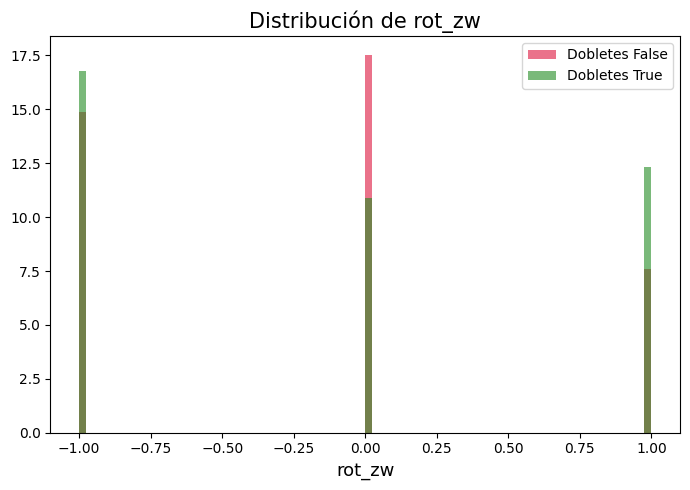

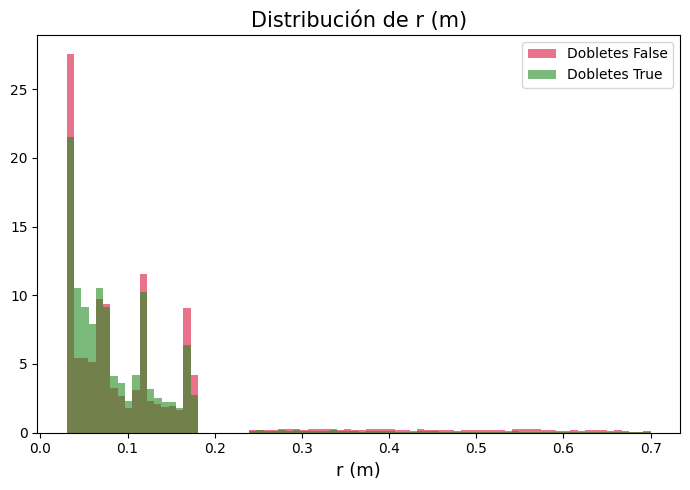

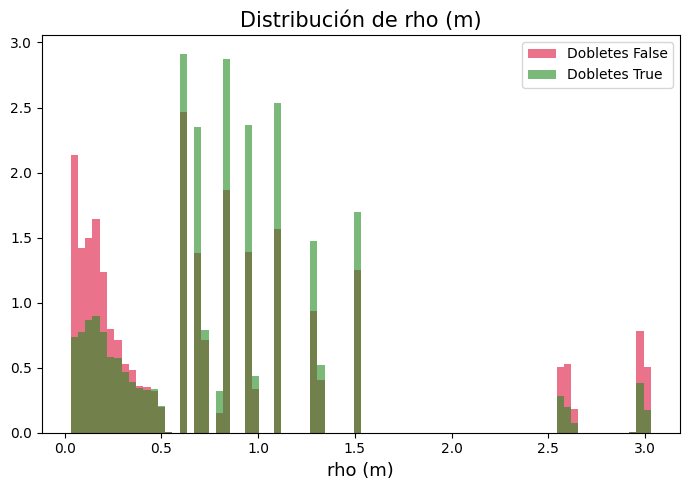

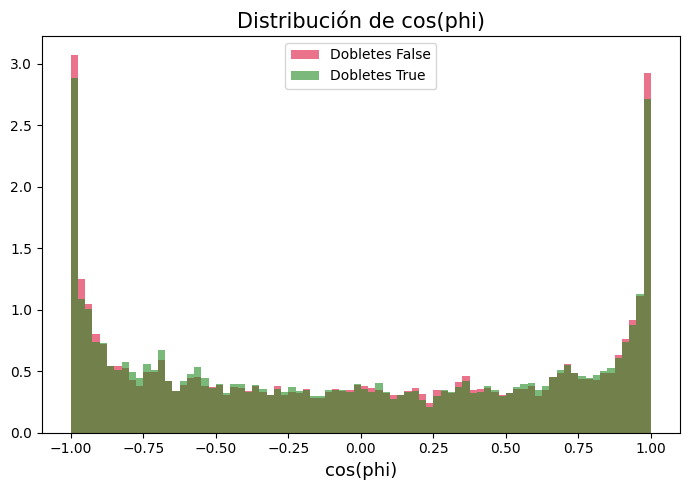

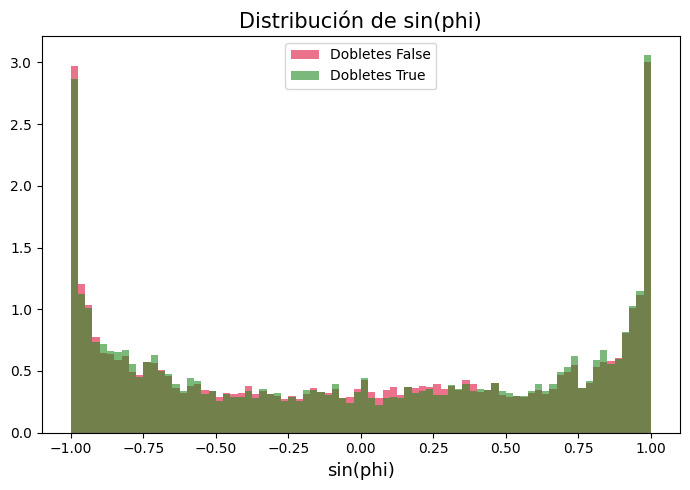

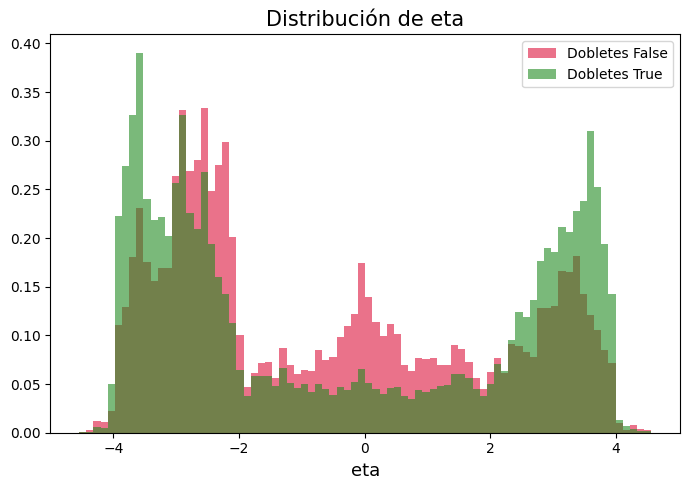

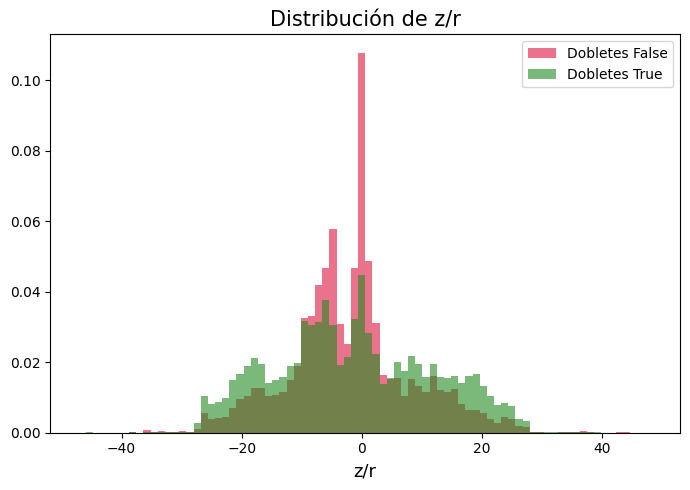

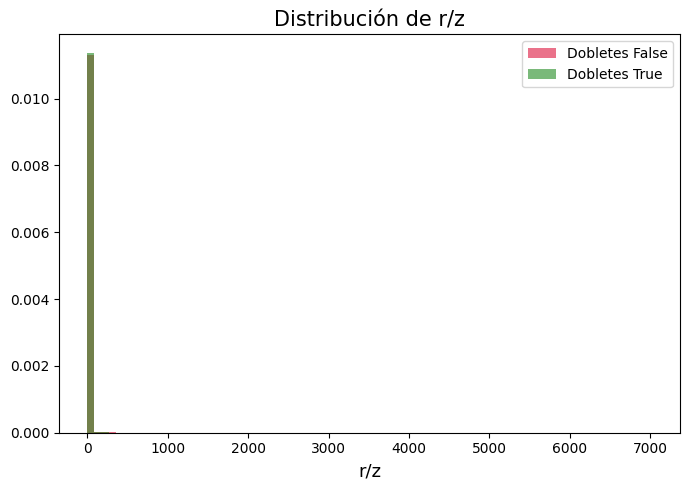

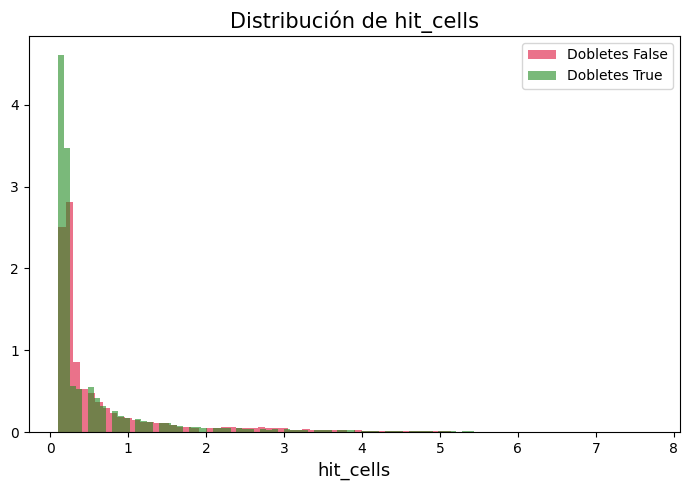

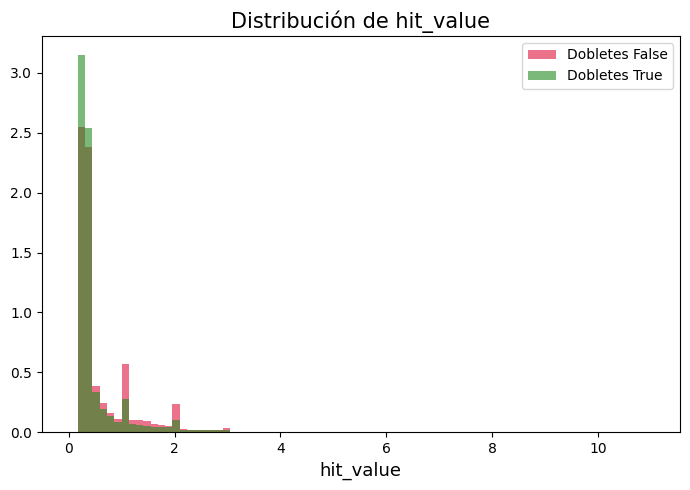

In [18]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["x (m)","y (m)","z (m)","cx (m)","cy (m)","cz (m)","rot_xw","rot_yw","rot_zw","r (m)","rho (m)","cos(phi)","sin(phi)","eta","z/r","r/z","hit_cells","hit_value"]
true_features = [[] for _ in range(features.shape[1])]
false_features = [[] for _ in range(features.shape[1])]

for i in range(len(preds)):

    vecinos = preds[i][0]

    for j in vecinos:

        misma = truth.particle_id.iloc[i] == truth.particle_id.iloc[j]

        for k in range(features.shape[1]):

            if misma:
                true_features[k].append(features[j,k])
            else:
                false_features[k].append(features[j,k])

for k,name in enumerate(feature_names):

    plt.figure(figsize=(7,5))

    plt.hist(false_features[k],bins=80,alpha=0.6,density=True, color="crimson",label="Dobletes False")

    plt.hist(true_features[k],bins=80,alpha=0.6,density=True, color="forestgreen",label="Dobletes True")

    plt.xlabel(name,fontsize=13)
    plt.title(f"Distribución de {name}",fontsize=15)
    plt.legend()

    plt.tight_layout()
    safe_name = (name.replace("/", "_").replace("(", "").replace(")", "").replace(" ", "_"))
    plt.savefig(f"{safe_name}.png",dpi=400)
    plt.show()

In [23]:
# Conjunto de validacion para SHAP
np.random.seed(42)

N_pairs = 93680

en = features.shape[1]          # 18
den = 2*en + 1                  # 37

X_val = np.zeros((N_pairs, den), dtype=np.float32)
y_val = np.zeros(N_pairs, dtype=np.float32)

n_hits = len(features)

for k in range(N_pairs):

    # Elegimos dos hits aleatorios
    i = np.random.randint(n_hits)
    j = np.random.randint(n_hits)

    while i == j:
        j = np.random.randint(n_hits)

    # Hit 1
    X_val[k,:en] = features[i]

    # Hit 2
    X_val[k,en:2*en] = features[j]

    # Variable DBSCAN
    X_val[k,2*en] = float(grupos[i] == grupos[j])

    # Etiqueta verdadera
    y_val[k] = float(
        truth.particle_id.iloc[i] ==
        truth.particle_id.iloc[j]
    )

print("Forma:",X_val.shape)
print("Positivos:",y_val.sum())
print("Negativos:",len(y_val)-y_val.sum())

X_val = torch.tensor(X_val,dtype=torch.float32).to(device)
y_val = torch.tensor(y_val,dtype=torch.float32).to(device)

Forma: (93680, 37)
Positivos: 3281.0
Negativos: 90399.0


In [27]:
pares =[]
features, grupos = features_hits(hits, cells, detectors) # Variables

# Obtenemos los particle_id verdaderos y eliminamos el ruido
particle_ids = truth.particle_id.unique()
particle_ids = particle_ids[particle_ids != 0]

# Primero. Creo pares de hits que sí pertenezcan a la misma partícula para entrenar la red neuronal en positivo.
pares_positivos = [] # Para guardar los hits producidos por las particulas
for p in particle_ids:
    # Extraigo los hits_id que corresponden a la misma partícula
    indices = truth.loc[truth.particle_id == p,'hit_id'].values - 1 # Con el -1 reindexamos los hits_id para empezar como en los arrays
    
    for i in indices:
        for j in indices:
            if i != j: # No queremos los pares (i,i) con los mismos índices
                pares_positivos.append([i,j])
                
pares_positivos = np.array(pares_positivos)

# Creamos un grupo con etiquetas con DBSCAN
same_cluster_p = (grupos[pares_positivos[:,0]] == grupos[pares_positivos[:,1]]).astype(np.float32)

# Creamos el conjunto de entrenamiento con los pares de hits que sabemos que pertenecen a las mismas partículas
# Obtenemos las features del primer índice del par y el segundo. Además añado un array de 1s indicando que sí pertenecen a la misma partícula
pos = np.column_stack([features[pares_positivos[:,0]], features[pares_positivos[:,1]], same_cluster_p, np.ones(len(pares_positivos))])

# Segundo. Creamos los pares para el entrenamiento en negativo. De manera aleatoria, que no pertenezcan a ninguna trayectoria real
# Haremos que el tamaño de estos pares sea 3 veces mayor que el del entrenamiento positivo.
n_hits = len(hits)
size = len(pos)*3

# Vector con el particle_id de cada hit
p = truth.particle_id.values

# Creo indices aleatorios en un array con valores máximos el número de hits de tamaño 3 veces el del entreno 1
i = np.random.randint(0,n_hits,size) 
j = np.random.randint(0,n_hits,size)

# Filtramos los pares para el entrenamiento negativo. Necesitamos que los particle_id sean distintos para que no pertenezcan a la misma partícula
# y si alguno es 0 tambien es negativo el entrenamiento
condicion_negativa = ((p[i] == 0)|(p[i] != p[j]))
pares_negativos = np.column_stack([i[condicion_negativa],j[condicion_negativa]])

# Creamos un grupo con etiquetas con DBSCAN
same_cluster_n = (grupos[pares_negativos[:,0]] == grupos[pares_negativos[:,1]]).astype(np.float32)

# Obtenemos las features del primer índice del par y el segundo. Añado como antes un array de 0s indicando que NO pertenecen a la misma partícula
neg = np.column_stack([features[pares_negativos[:,0]], features[pares_negativos[:,1]], same_cluster_n, np.zeros(len(pares_negativos))])
pares.append(pos)
pares.append(neg)

pares = np.vstack(pares) # Junto verticalmente el array de entreno
np.random.shuffle(pares) # Lo mezclo para que no queden todas las filas agrupadas

X = pares[:,:-1].astype(np.float32) # Elimino la columna de etiquetas de 1 y 0 para entrenar.
y = pares[:,-1].astype(np.float32) # Me quedo únicamente con las etiquetas.
print(pares.shape)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, shuffle=True, random_state=42)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).reshape(-1,1).to(device)


(3207658, 38)


Shape SHAP: (1000, 37)
Shape importancia: (37,)


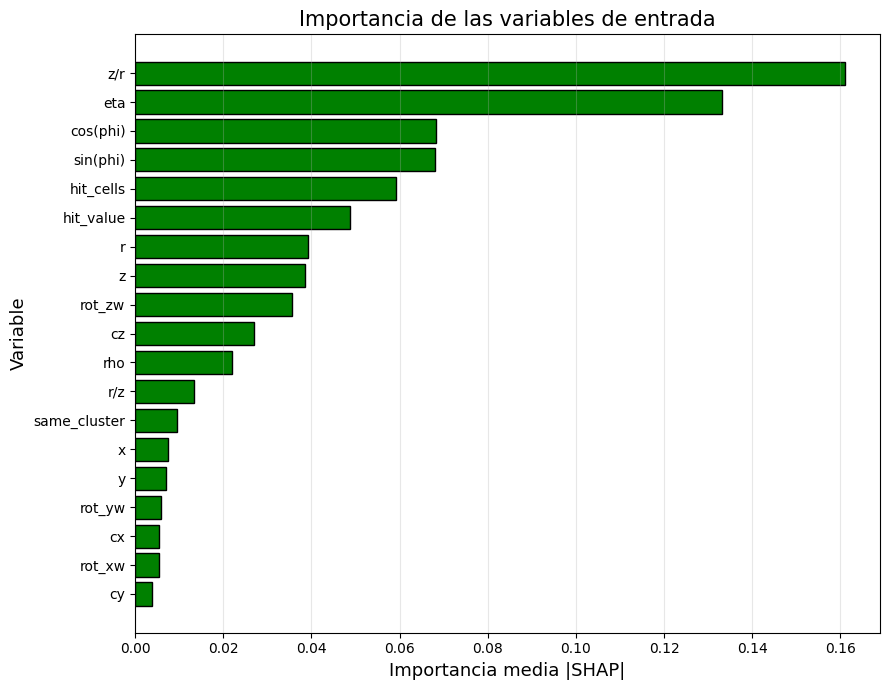

In [33]:
# Importancia de las variables con shap
# Si DeepExplainer devuelve una lista
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

# Si viene con dimensión extra (N,37,1)
shap_values = np.squeeze(shap_values)

print("Shape SHAP:", shap_values.shape)

# Importancia media absoluta
imp = np.abs(shap_values).mean(axis=0)

print("Shape importancia:", imp.shape)

importance = np.zeros(19)

for i in range(18):
    importance[i] = imp[i] + imp[i+18]

# Variable same_cluster
importance[18] = imp[36]

feature_names = [
    "x",
    "y",
    "z",
    "cx",
    "cy",
    "cz",
    "rot_xw",
    "rot_yw",
    "rot_zw",
    "r",
    "rho",
    "cos(phi)",
    "sin(phi)",
    "eta",
    "z/r",
    "r/z",
    "hit_cells",
    "hit_value",
    "same_cluster"
]

# ==========================================================
# ORDENAMOS
# ==========================================================

orden = np.argsort(importance)

# ==========================================================
# FIGURA
# ==========================================================

plt.figure(figsize=(9,7))

plt.barh(np.array(feature_names)[orden],importance[orden],color="green",edgecolor="black")

plt.xlabel("Importancia media |SHAP|", fontsize=13)
plt.ylabel("Variable", fontsize=13)
plt.title("Importancia de las variables de entrada", fontsize=15)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig("SHAP_importance.png", dpi=600)
plt.savefig("SHAP_importance.pdf")

plt.show()